<a href="https://colab.research.google.com/github/zubairaziz132/Complete-Python-3-Bootcamp/blob/master/SalesAnalysisProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AAL SALES ANALYSIS - FOURTH QUARTER 2020
Applied Data Science Project

📊 LOADING AND EXPLORING DATA
----------------------------------------
✅ Data loaded successfully!
📋 Dataset shape: (7560, 6)

📈 Dataset Overview:
         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500

🔍 Data Types:
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-nul

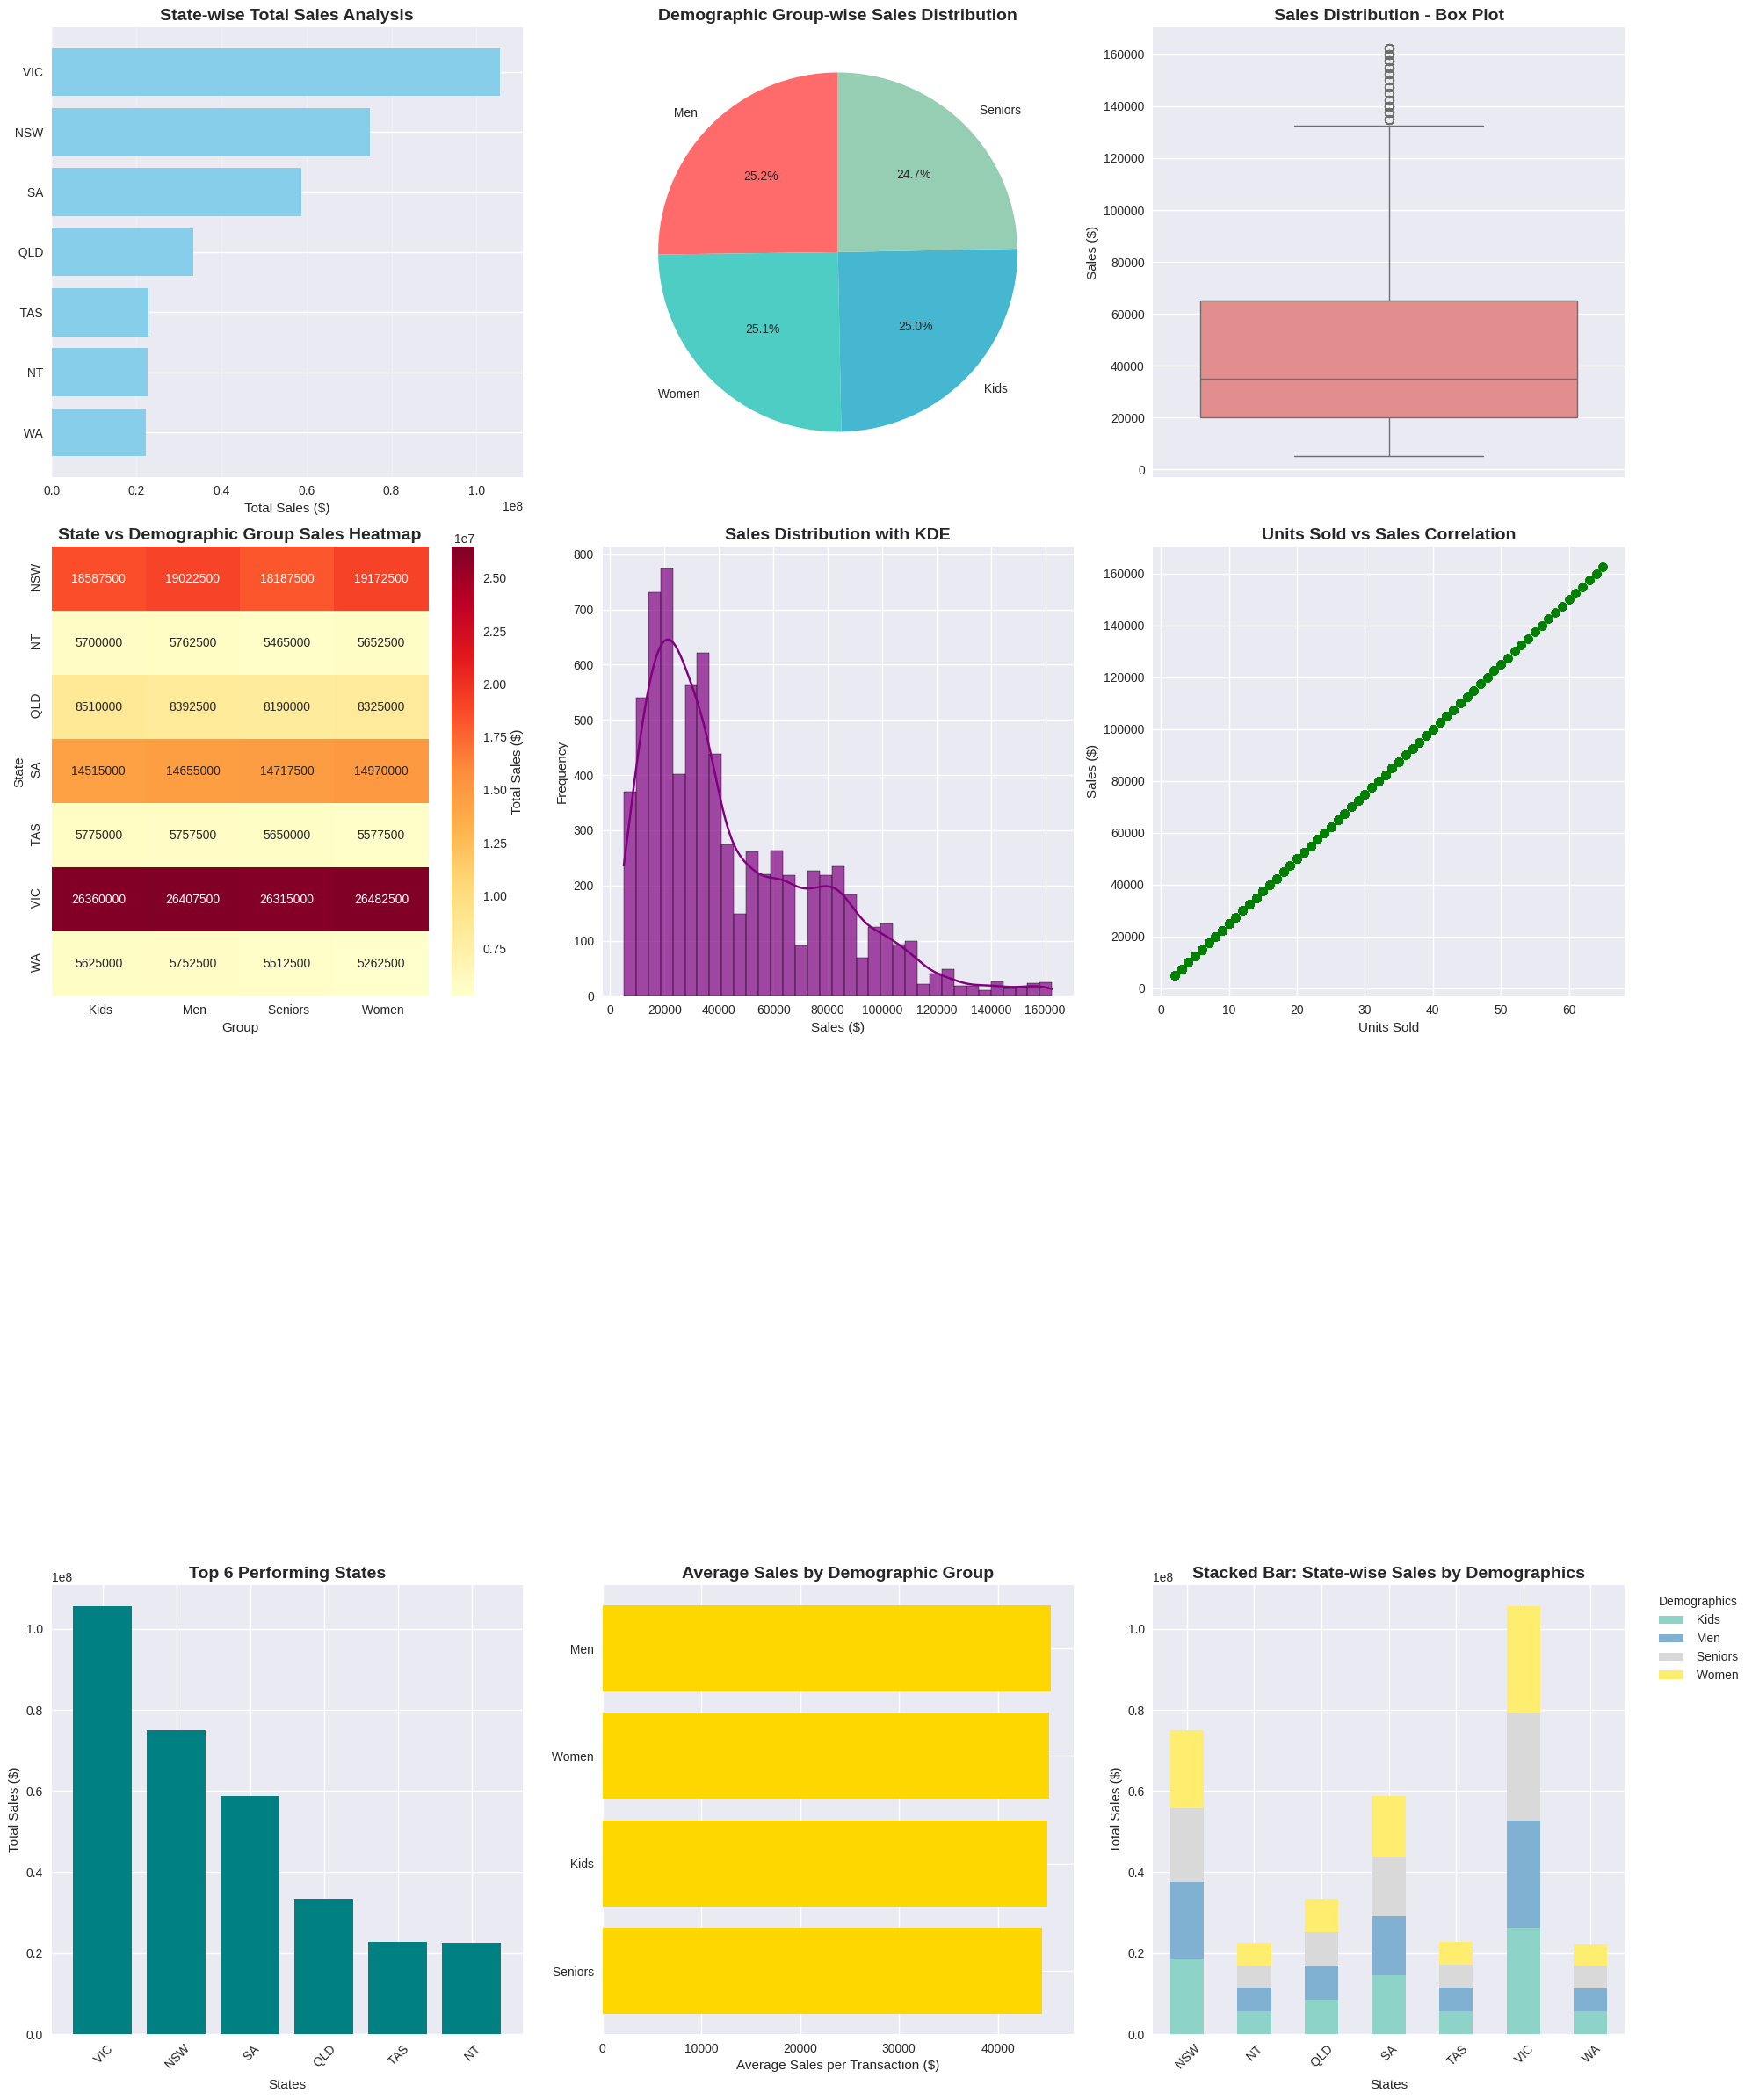

✅ Dashboard created successfully!

📊 CREATING DETAILED VISUALIZATIONS
---------------------------------------------


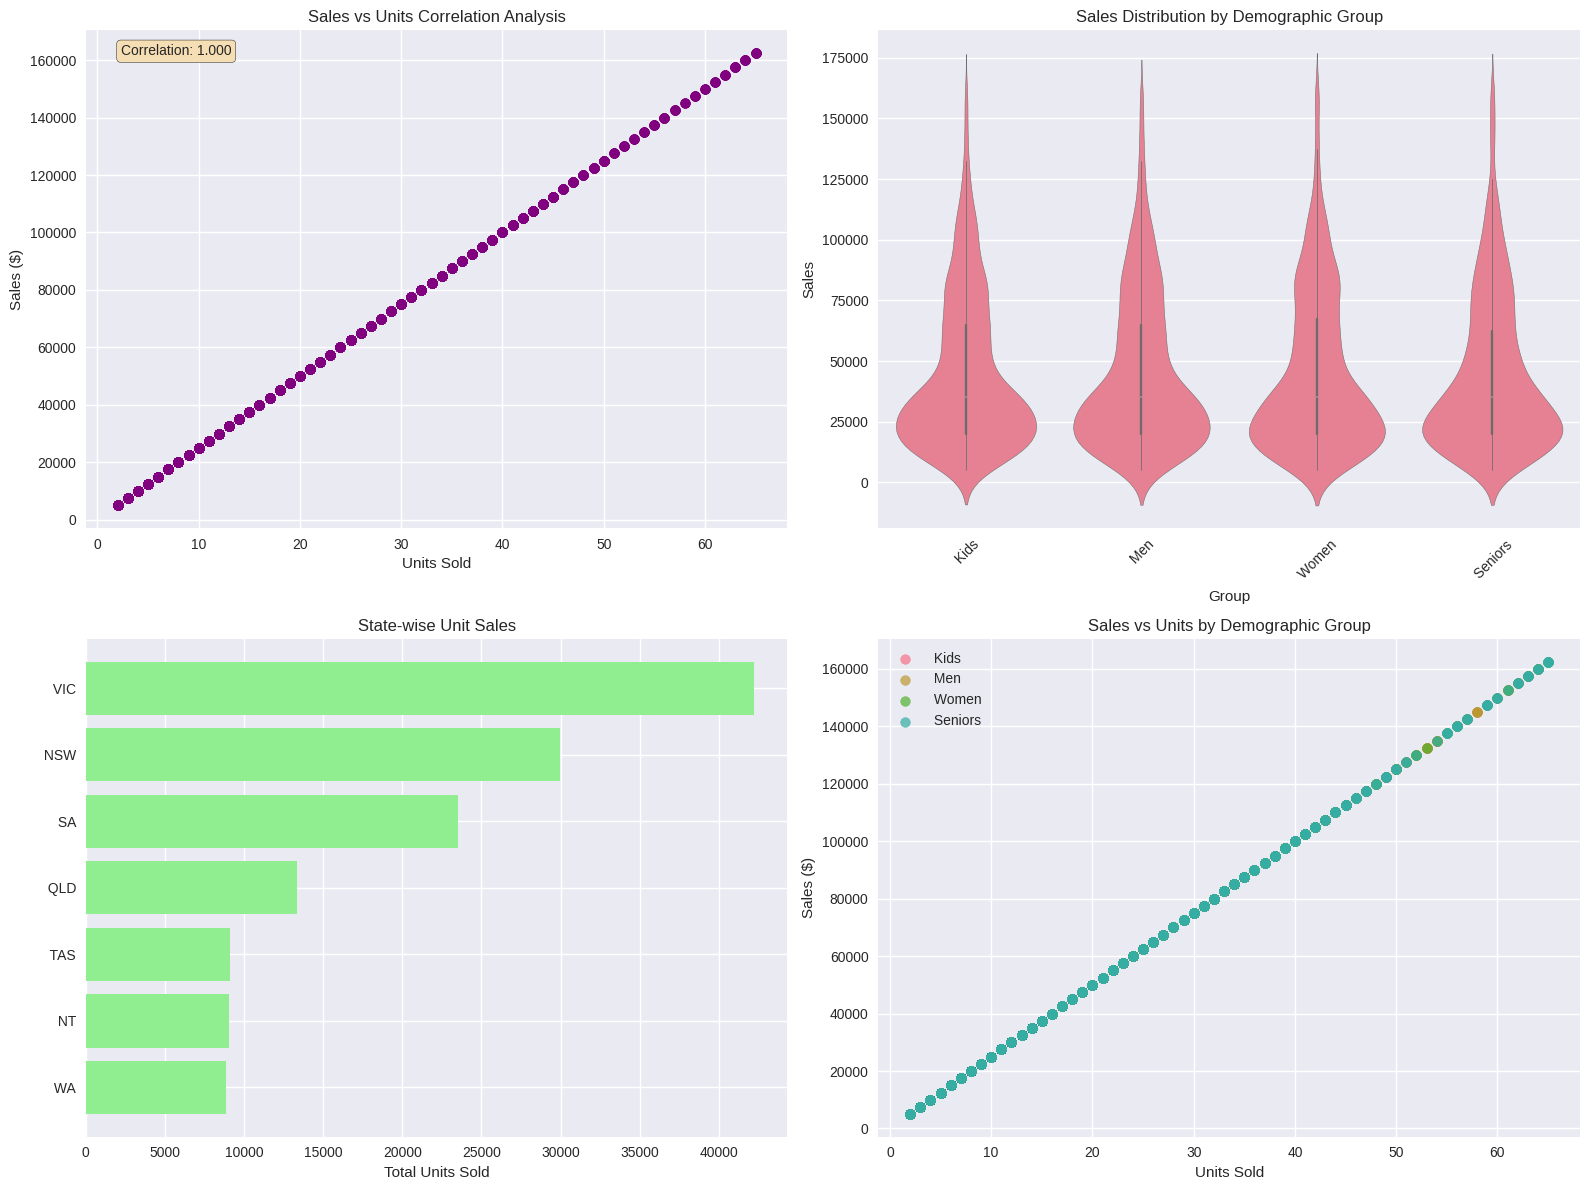

✅ Detailed visualizations created successfully!

💼 BUSINESS RECOMMENDATIONS
🌟 KEY FINDINGS:
--------------------
1. Top Revenue Generating States:
   1.  VIC: $105,565,000.00
   2.  NSW: $74,970,000.00
   3.  SA: $58,857,500.00

2. States Requiring Sales Programs:
   1.  TAS: $22,760,000.00
   2.  NT: $22,580,000.00
   3.  WA: $22,152,500.00

3. Demographic Performance:
   🏆 Best Performing:  Men ($85,750,000.00)
   📈 Needs Attention:  Seniors ($84,037,500.00)

💡 STRATEGIC RECOMMENDATIONS:
-----------------------------------
📈 FOR HIGH-PERFORMING STATES:
   •  VIC: Expand product range and increase inventory
   •  NSW: Expand product range and increase inventory
   •  SA: Expand product range and increase inventory

🚀 FOR UNDERPERFORMING STATES:
   •  TAS: Implement targeted marketing campaigns
     - Focus on  Men demographic (highest performing)
     - Increase promotional activities
     - Consider local partnerships
   •  NT: Implement targeted marketing campaigns
     - Focus on  

In [7]:
# AAL Sales Analysis - Fourth Quarter 2020
# Applied Data Science Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 60)
print("AAL SALES ANALYSIS - FOURTH QUARTER 2020")
print("Applied Data Science Project")
print("=" * 60)

# ============================================================================
# 1. DATA LOADING AND INITIAL EXPLORATION
# ============================================================================

def load_and_explore_data(file_path):
    """
    Load the Excel file and perform initial data exploration
    """
    print("\n📊 LOADING AND EXPLORING DATA")
    print("-" * 40)

    try:
        # Load the CSV file
        df = pd.read_csv(file_path)
        print(f"✅ Data loaded successfully!")
        print(f"📋 Dataset shape: {df.shape}")

        # Display basic information
        print(f"\n📈 Dataset Overview:")
        print(df.head())

        print(f"\n🔍 Data Types:")
        print(df.dtypes)

        print(f"\n📊 Dataset Info:")
        print(df.info())

        return df

    except Exception as e:
        print(f"❌ Error loading file: {e}")
        return None

# ============================================================================
# 2. DATA WRANGLING
# ============================================================================

def data_wrangling(df):
    """
    Comprehensive data wrangling including cleaning, missing value treatment, and normalization
    """
    print("\n🔧 DATA WRANGLING")
    print("-" * 40)

    # Create a copy to preserve original data
    df_clean = df.copy()

    # a. Check for missing and incorrect entries
    print("🔍 Checking for missing values:")
    missing_data = df_clean.isnull().sum()
    print(missing_data)

    print(f"\n📊 Missing value percentages:")
    missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100
    missing_info = pd.DataFrame({
        'Missing Count': missing_data,
        'Percentage': missing_percent
    })
    print(missing_info)

    # Check for incorrect entries
    print(f"\n🔍 Checking for potential data quality issues:")

    # Check for negative values in Sales and Unit columns
    if 'Sales' in df_clean.columns:
        negative_sales = df_clean[df_clean['Sales'] < 0]
        print(f"Negative sales entries: {len(negative_sales)}")

    if 'Unit' in df_clean.columns:
        negative_units = df_clean[df_clean['Unit'] < 0]
        print(f"Negative unit entries: {len(negative_units)}")

    # Check for duplicate entries
    duplicates = df_clean.duplicated().sum()
    print(f"Duplicate entries: {duplicates}")

    # b. Treat missing and incorrect data
    print(f"\n🔧 Data Cleaning Recommendations and Actions:")

    # Remove duplicates if any
    if duplicates > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"✅ Removed {duplicates} duplicate entries")

    # Handle missing values based on column type
    for column in df_clean.columns:
        if df_clean[column].isnull().sum() > 0:
            if df_clean[column].dtype in ['int64', 'float64']:
                # For numerical columns, use median
                median_val = df_clean[column].median()
                df_clean[column].fillna(median_val, inplace=True)
                print(f"✅ Filled {column} missing values with median: {median_val}")
            else:
                # For categorical columns, use mode
                mode_val = df_clean[column].mode()[0] if len(df_clean[column].mode()) > 0 else 'Unknown'
                df_clean[column].fillna(mode_val, inplace=True)
                print(f"✅ Filled {column} missing values with mode: {mode_val}")

    # Remove negative values in Sales and Unit columns
    original_len = len(df_clean)
    if 'Sales' in df_clean.columns:
        df_clean = df_clean[df_clean['Sales'] >= 0]
    if 'Unit' in df_clean.columns:
        df_clean = df_clean[df_clean['Unit'] >= 0]

    removed_rows = original_len - len(df_clean)
    if removed_rows > 0:
        print(f"✅ Removed {removed_rows} rows with negative values")

    # c. Data Normalization (Min-Max Normalization)
    print(f"\n📊 Applying Min-Max Normalization:")

    # Identify numerical columns for normalization
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

    # Remove Date/Time related columns from normalization if present
    exclude_cols = ['Date', 'DateTime', 'Year', 'Month', 'Day']
    numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

    # Apply Min-Max normalization
    for col in numerical_cols:
        if col in ['Sales', 'Unit']:
            min_val = df_clean[col].min()
            max_val = df_clean[col].max()
            df_clean[f'{col}_normalized'] = (df_clean[col] - min_val) / (max_val - min_val)
            print(f"✅ Normalized {col}: Min={min_val:.2f}, Max={max_val:.2f}")

    # d. GroupBy Analysis and Recommendations
    print(f"\n👥 GroupBy Analysis and Recommendations:")

    if 'State' in df_clean.columns and 'Group' in df_clean.columns:
        # Analyze data structure for grouping recommendations
        state_groups = df_clean.groupby('State')['Sales'].agg(['count', 'sum', 'mean']).round(2)
        demographic_groups = df_clean.groupby('Group')['Sales'].agg(['count', 'sum', 'mean']).round(2)

        print("📊 State-wise Sales Summary:")
        print(state_groups.head())

        print("\n📊 Demographic Group-wise Sales Summary:")
        print(demographic_groups)

        print(f"\n💡 GroupBy Recommendations:")
        print("1. Use State grouping for geographical analysis and expansion decisions")
        print("2. Use Group (demographic) grouping for targeted marketing campaigns")
        print("3. Consider State-Group combination for localized demographic strategies")

    print(f"\n✅ Data Wrangling Complete!")
    print(f"📊 Clean dataset shape: {df_clean.shape}")

    return df_clean

# ============================================================================
# 3. DATA ANALYSIS
# ============================================================================

def descriptive_analysis(df):
    """
    Perform comprehensive descriptive statistical analysis
    """
    print("\n📈 DESCRIPTIVE STATISTICAL ANALYSIS")
    print("-" * 50)

    # a. Descriptive statistics for Sales and Unit columns
    numerical_cols = ['Sales', 'Unit']

    for col in numerical_cols:
        if col in df.columns:
            print(f"\n📊 Descriptive Statistics for {col}:")
            print("-" * 30)

            # Basic statistics
            stats_summary = {
                'Count': df[col].count(),
                'Mean': df[col].mean(),
                'Median': df[col].median(),
                'Mode': df[col].mode().iloc[0] if len(df[col].mode()) > 0 else np.nan,
                'Standard Deviation': df[col].std(),
                'Variance': df[col].var(),
                'Minimum': df[col].min(),
                'Maximum': df[col].max(),
                'Range': df[col].max() - df[col].min(),
                '25th Percentile': df[col].quantile(0.25),
                '75th Percentile': df[col].quantile(0.75),
                'IQR': df[col].quantile(0.75) - df[col].quantile(0.25),
                'Skewness': stats.skew(df[col].dropna()),
                'Kurtosis': stats.kurtosis(df[col].dropna())
            }

            for stat, value in stats_summary.items():
                print(f"{stat}: {value:.2f}")

    # b. & c. Identify highest and lowest performing groups
    print(f"\n🏆 PERFORMANCE ANALYSIS")
    print("-" * 30)

    # State-wise analysis
    if 'State' in df.columns:
        state_sales = df.groupby('State')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        state_sales = state_sales.sort_values('sum', ascending=False)

        print("🌟 State-wise Sales Performance:")
        print(state_sales)

        print(f"\n🥇 Highest Revenue State: {state_sales.index[0]} (${state_sales.iloc[0]['sum']:.2f})")
        print(f"🔻 Lowest Revenue State: {state_sales.index[-1]} (${state_sales.iloc[-1]['sum']:.2f})")

    # Group-wise analysis
    if 'Group' in df.columns:
        group_sales = df.groupby('Group')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        group_sales = group_sales.sort_values('sum', ascending=False)

        print(f"\n🎯 Demographic Group-wise Sales Performance:")
        print(group_sales)

        # Check if group_sales is not empty before accessing index
        if not group_sales.empty:
            top_group = group_sales.index[0]
            bottom_group = group_sales.index[-1]
            print(f"\n🥇 Highest Revenue Group: {top_group} (${group_sales.loc[top_group, 'sum']:,.2f})")
            print(f"🔻 Lowest Revenue Group: {bottom_group} (${group_sales.loc[bottom_group, 'sum']:,.2f})")
        else:
            print("\n⚠️ Group sales data is empty.")


    return state_sales, group_sales

def generate_time_reports(df):
    """
    Generate weekly, monthly, and quarterly reports
    """
    print(f"\n📅 TIME-BASED REPORTING")
    print("-" * 30)

    # Convert DateTime column if present
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df['Date'] = df['DateTime'].dt.date
        df['Week'] = df['DateTime'].dt.isocalendar().week
        df['Month'] = df['DateTime'].dt.month
        df['Quarter'] = df['DateTime'].dt.quarter
        df['Hour'] = df['DateTime'].dt.hour
        df['DayOfWeek'] = df['DateTime'].dt.dayofweek

        # Weekly Report
        print("📊 Weekly Sales Report:")
        weekly_report = df.groupby('Week')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        print(weekly_report)

        # Monthly Report
        print(f"\n📊 Monthly Sales Report:")
        monthly_report = df.groupby('Month')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        print(monthly_report)

        # Quarterly Report
        print(f"\n📊 Quarterly Sales Report:")
        quarterly_report = df.groupby('Quarter')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        print(quarterly_report)

        # Time of day analysis
        print(f"\n🕐 Time-of-Day Analysis:")
        hourly_report = df.groupby('Hour')['Sales'].agg(['sum', 'mean', 'count']).round(2)
        peak_hour = hourly_report['sum'].idxmax()
        off_peak_hour = hourly_report['sum'].idxmin()

        print(f"🔥 Peak Sales Hour: {peak_hour}:00 (${hourly_report.loc[peak_hour, 'sum']:.2f})")
        print(f"📉 Off-Peak Sales Hour: {off_peak_hour}:00 (${hourly_report.loc[off_peak_hour, 'sum']:.2f})")

        return weekly_report, monthly_report, quarterly_report, hourly_report

    else:
        print("⚠️ DateTime column not found. Cannot generate time-based reports.")
        return None, None, None, None

# ============================================================================
# 4. DATA VISUALIZATION
# ============================================================================

def create_dashboard(df, state_sales, group_sales):
    """
    Create comprehensive dashboard for sales analysis
    """
    print(f"\n📊 CREATING SALES DASHBOARD")
    print("-" * 40)

    # Set up the dashboard layout
    fig = plt.figure(figsize=(20, 24))

    # 1. State-wise Sales Analysis
    plt.subplot(4, 3, 1)
    state_sales_sorted = state_sales.sort_values('sum', ascending=True)
    plt.barh(range(len(state_sales_sorted)), state_sales_sorted['sum'], color='skyblue')
    plt.yticks(range(len(state_sales_sorted)), state_sales_sorted.index)
    plt.xlabel('Total Sales ($)')
    plt.title('State-wise Total Sales Analysis', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)

    # 2. Group-wise Sales Analysis
    plt.subplot(4, 3, 2)
    group_sales_sorted = group_sales.sort_values('sum', ascending=False)
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    plt.pie(group_sales_sorted['sum'], labels=group_sales_sorted.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    plt.title('Demographic Group-wise Sales Distribution', fontsize=14, fontweight='bold')

    # 3. Box plot for Sales (Descriptive Statistics)
    plt.subplot(4, 3, 3)
    sns.boxplot(data=df, y='Sales', color='lightcoral')
    plt.title('Sales Distribution - Box Plot', fontsize=14, fontweight='bold')
    plt.ylabel('Sales ($)')

    # 4. State vs Group Heatmap
    plt.subplot(4, 3, 4)
    if 'State' in df.columns and 'Group' in df.columns:
        pivot_table = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum')
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Total Sales ($)'})
        plt.title('State vs Demographic Group Sales Heatmap', fontsize=14, fontweight='bold')

    # 5. Sales Distribution Plot
    plt.subplot(4, 3, 5)
    sns.histplot(data=df, x='Sales', kde=True, color='purple', alpha=0.7)
    plt.title('Sales Distribution with KDE', fontsize=14, fontweight='bold')
    plt.xlabel('Sales ($)')
    plt.ylabel('Frequency')

    # 6. Unit vs Sales Scatter Plot
    plt.subplot(4, 3, 6)
    plt.scatter(df['Unit'], df['Sales'], alpha=0.6, color='green')
    plt.xlabel('Units Sold')
    plt.ylabel('Sales ($)')
    plt.title('Units Sold vs Sales Correlation', fontsize=14, fontweight='bold')

    # Time-based analysis (if DateTime is available)
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df['Hour'] = df['DateTime'].dt.hour
        df['DayOfWeek'] = df['DateTime'].dt.dayofweek
        df['Month'] = df['DateTime'].dt.month

        # 7. Hourly Sales Pattern
        plt.subplot(4, 3, 7)
        hourly_sales = df.groupby('Hour')['Sales'].sum()
        plt.plot(hourly_sales.index, hourly_sales.values, marker='o', linewidth=2, color='red')
        plt.xlabel('Hour of Day')
        plt.ylabel('Total Sales ($)')
        plt.title('Daily Sales Pattern by Hour', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # 8. Day of Week Sales
        plt.subplot(4, 3, 8)
        days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        dow_sales = df.groupby('DayOfWeek')['Sales'].sum()
        plt.bar(range(7), dow_sales.values, color='orange')
        plt.xticks(range(7), days)
        plt.xlabel('Day of Week')
        plt.ylabel('Total Sales ($)')
        plt.title('Weekly Sales Pattern', fontsize=14, fontweight='bold')

        # 9. Monthly Sales Trend
        plt.subplot(4, 3, 9)
        monthly_sales = df.groupby('Month')['Sales'].sum()
        plt.plot(monthly_sales.index, monthly_sales.values, marker='s', linewidth=3, color='blue')
        plt.xlabel('Month')
        plt.ylabel('Total Sales ($)')
        plt.title('Q4 Monthly Sales Trend', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

    # 10. Top States Performance
    plt.subplot(4, 3, 10)
    top_states = state_sales.head(6)
    plt.bar(range(len(top_states)), top_states['sum'], color='teal')
    plt.xticks(range(len(top_states)), top_states.index, rotation=45)
    plt.xlabel('States')
    plt.ylabel('Total Sales ($)')
    plt.title('Top 6 Performing States', fontsize=14, fontweight='bold')

    # 11. Group Performance by Average Sales
    plt.subplot(4, 3, 11)
    avg_group_sales = group_sales.sort_values('mean', ascending=True)
    plt.barh(range(len(avg_group_sales)), avg_group_sales['mean'], color='gold')
    plt.yticks(range(len(avg_group_sales)), avg_group_sales.index)
    plt.xlabel('Average Sales per Transaction ($)')
    plt.title('Average Sales by Demographic Group', fontsize=14, fontweight='bold')

    # 12. Combined State-Group Analysis
    plt.subplot(4, 3, 12)
    if 'State' in df.columns and 'Group' in df.columns:
        state_group_sales = df.groupby(['State', 'Group'])['Sales'].sum().unstack().fillna(0)
        state_group_sales.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set3')
        plt.xlabel('States')
        plt.ylabel('Total Sales ($)')
        plt.title('Stacked Bar: State-wise Sales by Demographics', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.legend(title='Demographics', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    print("✅ Dashboard created successfully!")

def create_detailed_visualizations(df):
    """
    Create additional detailed visualizations
    """
    print(f"\n📊 CREATING DETAILED VISUALIZATIONS")
    print("-" * 45)

    # Additional Analysis Plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Sales vs Units correlation
    axes[0, 0].scatter(df['Unit'], df['Sales'], alpha=0.6, color='purple')
    axes[0, 0].set_xlabel('Units Sold')
    axes[0, 0].set_ylabel('Sales ($)')
    axes[0, 0].set_title('Sales vs Units Correlation Analysis')

    # Calculate and display correlation
    correlation = df['Unit'].corr(df['Sales'])
    axes[0, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}',
                    transform=axes[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

    # 2. Sales distribution by Group
    if 'Group' in df.columns:
        sns.violinplot(data=df, x='Group', y='Sales', ax=axes[0, 1])
        axes[0, 1].set_title('Sales Distribution by Demographic Group')
        axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. State-wise Unit Sales
    if 'State' in df.columns:
        state_units = df.groupby('State')['Unit'].sum().sort_values(ascending=True)
        axes[1, 0].barh(range(len(state_units)), state_units.values, color='lightgreen')
        axes[1, 0].set_yticks(range(len(state_units)))
        axes[1, 0].set_yticklabels(state_units.index)
        axes[1, 0].set_xlabel('Total Units Sold')
        axes[1, 0].set_title('State-wise Unit Sales')

    # 4. Sales vs Units by Group
    if 'Group' in df.columns:
        for group in df['Group'].unique():
            group_data = df[df['Group'] == group]
            axes[1, 1].scatter(group_data['Unit'], group_data['Sales'],
                             label=group, alpha=0.7, s=50)
        axes[1, 1].set_xlabel('Units Sold')
        axes[1, 1].set_ylabel('Sales ($)')
        axes[1, 1].set_title('Sales vs Units by Demographic Group')
        axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    print("✅ Detailed visualizations created successfully!")

# ============================================================================
# 5. REPORT GENERATION AND RECOMMENDATIONS
# ============================================================================

def generate_business_recommendations(df, state_sales, group_sales):
    """
    Generate comprehensive business recommendations
    """
    print(f"\n💼 BUSINESS RECOMMENDATIONS")
    print("=" * 50)

    # High Revenue States
    top_3_states = state_sales.head(3)
    bottom_3_states = state_sales.tail(3)

    print("🌟 KEY FINDINGS:")
    print("-" * 20)
    print(f"1. Top Revenue Generating States:")
    for i, (state, data) in enumerate(top_3_states.iterrows(), 1):
        print(f"   {i}. {state}: ${data['sum']:,.2f}")

    print(f"\n2. States Requiring Sales Programs:")
    for i, (state, data) in enumerate(bottom_3_states.iterrows(), 1):
        print(f"   {i}. {state}: ${data['sum']:,.2f}")

    # Group Performance
    if not group_sales.empty:
        top_group = group_sales.index[0]
        bottom_group = group_sales.index[-1]

        print(f"\n3. Demographic Performance:")
        print(f"   🏆 Best Performing: {top_group} (${group_sales.loc[top_group, 'sum']:,.2f})")
        print(f"   📈 Needs Attention: {bottom_group} (${group_sales.loc[bottom_group, 'sum']:,.2f})")

        print(f"\n💡 STRATEGIC RECOMMENDATIONS:")
        print("-" * 35)

        print("📈 FOR HIGH-PERFORMING STATES:")
        for state in top_3_states.index[:3]:
            print(f"   • {state}: Expand product range and increase inventory")

        print(f"\n🚀 FOR UNDERPERFORMING STATES:")
        for state in bottom_3_states.index:
            print(f"   • {state}: Implement targeted marketing campaigns")
            print(f"     - Focus on {top_group} demographic (highest performing)")
            print(f"     - Increase promotional activities")
            print(f"     - Consider local partnerships")

        print(f"\n🎯 DEMOGRAPHIC STRATEGIES:")
        print(f"   • Leverage {top_group} success model for other demographics")
        print(f"   • Develop specialized campaigns for {bottom_group}")
        print(f"   • Cross-demographic marketing opportunities")
    else:
        print("\n⚠️ Cannot generate demographic-based recommendations as group sales data is empty.")


    if 'DateTime' in df.columns:
        df['Hour'] = pd.to_datetime(df['DateTime']).dt.hour
        peak_hours = df.groupby('Hour')['Sales'].sum().nlargest(3)

        print(f"\n⏰ OPERATIONAL RECOMMENDATIONS:")
        print(f"   • Peak sales hours: {', '.join([f'{h}:00' for h in peak_hours.index])}")
        print(f"   • Optimize staffing during peak hours")
        print(f"   • Schedule promotions during high-traffic periods")

def main():
    """
    Main function to execute the complete analysis
    """
    # File path - Update this with your CSV file path
    file_path = "AusApparalSales4thQrt2020.csv"  # Update with your file path

    try:
        # 1. Load and explore data
        df = load_and_explore_data(file_path)
        if df is None:
            return

        # 2. Data wrangling
        df_clean = data_wrangling(df)

        # 3. Data analysis
        state_sales, group_sales = descriptive_analysis(df_clean)

        # 4. Generate time-based reports
        weekly_report, monthly_report, quarterly_report, hourly_report = generate_time_reports(df_clean)

        # 5. Create visualizations
        create_dashboard(df_clean, state_sales, group_sales)
        create_detailed_visualizations(df_clean)

        # 6. Generate business recommendations
        generate_business_recommendations(df_clean, state_sales, group_sales)

        print(f"\n✅ ANALYSIS COMPLETE!")
        print("=" * 50)
        print("📊 All analyses, visualizations, and recommendations have been generated.")
        print("💾 Save this notebook to preserve all outputs and insights.")

    except Exception as e:
        print(f"❌ Error in main execution: {e}")
        print("Please check your file path and data format.")

# ============================================================================
# EXECUTE THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    main()

# ============================================================================
# ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_summary_report(df, state_sales, group_sales):
    """
    Export summary statistics to Excel file
    """
    try:
        with pd.ExcelWriter('AAL_Sales_Analysis_Summary.xlsx') as writer:
            # Export cleaned data
            df.to_excel(writer, sheet_name='Clean_Data', index=False)

            # Export state analysis
            state_sales.to_excel(writer, sheet_name='State_Analysis')

            # Export group analysis
            group_sales.to_excel(writer, sheet_name='Group_Analysis')

            # Export summary statistics
            summary_stats = df[['Sales', 'Unit']].describe()
            summary_stats.to_excel(writer, sheet_name='Summary_Statistics')

        print("📁 Summary report exported to 'AAL_Sales_Analysis_Summary.xlsx'")

    except Exception as e:
        print(f"❌ Error exporting summary: {e}")

# Uncomment the line below to export summary report
# export_summary_report(df_clean, state_sales, group_sales)